In [ ]:
!pip install opencv-python

  Using cached numpy-2.2.5-cp310-cp310-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   - -------------------------------------- 1.0/39.5 MB 25.4 MB/s eta 0:00:02
   --- ------------------------------------ 3.1/39.5 MB 8.8 MB/s eta 0:00:05
   --- ------------------------------------ 3.7/39.5 MB 6.1 MB/s eta 0:00:06
   -------- ------------------------------- 8.7/39.5 MB 8.5 MB/s eta 0:00:04
   ----------------- ---------------------- 17.6/39.5 MB 12.9 MB/s eta 0:00:02
   -------------------------- ------------- 26.0/39.5 MB 16.4 MB/s eta 0:00:01
   ----------------------------- ---------- 29.1/39.5 MB 17.4 MB/s eta 0:00:01
   -------------------------------- ------- 32.5/39.5 MB 16.3 MB/s eta 0:00:01
   ---------------------------------------  38.5/39.5 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------  39.3/39.5 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 15.4 MB/s eta 0:00:0


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import cv2
import numpy as np
import gc

In [ ]:
# 입력 루트 디렉터리
root_dir = "D:/data/open/train"
output_dir = "D:/data/open/npy/train"  # npy 저장 경로
os.makedirs(output_dir, exist_ok=True)

In [ ]:
def crop_or_pad_center(img, target_size=64):
    h, w = img.shape[:2]
    top = max((h - target_size) // 2, 0)
    left = max((w - target_size) // 2, 0)
    bottom = top + target_size
    right = left + target_size
    cropped = img[top:bottom, left:right]

    # padding이 필요한 경우
    pad_h = max(target_size - cropped.shape[0], 0)
    pad_w = max(target_size - cropped.shape[1], 0)
    padded = cv2.copyMakeBorder(
        cropped,
        top=pad_h // 2,
        bottom=pad_h - pad_h // 2,
        left=pad_w // 2,
        right=pad_w - pad_w // 2,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )
    return padded

In [ ]:
target_size = 64

In [ ]:
# 각 하위 폴더 처리
for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    if not os.path.isdir(folder_path):
        continue

    print(f"Processing folder: {folder_name}")
    images = []
    batch_idx = 1
    save_count = 0

    # 이미지 파일 처리
    file_list = sorted(os.listdir(folder_path))
    for file_name in file_list:
        file_path = os.path.join(folder_path, file_name)
        img = cv2.imread(file_path)
        if img is None:
            continue

        # center crop and pad to small size
        img_cropped = crop_or_pad_center(img, target_size)

        # uint8로 변환
        img_cropped = img_cropped.astype(np.uint8)

        images.append(img_cropped)
        save_count += 1

        # 1000개마다 저장
        if len(images) == 1000:
            save_name = f"{folder_name}_{batch_idx:06d}.npy"
            save_path = os.path.join(output_dir, save_name)
            np.save(save_path, np.array(images))
            print(f"Saved {save_name} ({save_count} images)")
            images = []
            batch_idx += 1
            gc.collect()

    # 남은 이미지 저장
    if images:
        save_name = f"{folder_name}_{batch_idx:06d}.npy"
        save_path = os.path.join(output_dir, save_name)
        np.save(save_path, np.array(images))
        print(f"Saved {save_name} ({save_count} images)")

print("All done.")


Processing folder: Andesite
Saved Andesite_000001.npy (1000 images)
Saved Andesite_000002.npy (2000 images)
Saved Andesite_000003.npy (3000 images)
Saved Andesite_000004.npy (4000 images)
Saved Andesite_000005.npy (5000 images)
Saved Andesite_000006.npy (6000 images)
Saved Andesite_000007.npy (7000 images)
Saved Andesite_000008.npy (8000 images)
Saved Andesite_000009.npy (9000 images)
Saved Andesite_000010.npy (10000 images)
Saved Andesite_000011.npy (11000 images)
Saved Andesite_000012.npy (12000 images)
Saved Andesite_000013.npy (13000 images)
Saved Andesite_000014.npy (14000 images)
Saved Andesite_000015.npy (15000 images)
Saved Andesite_000016.npy (16000 images)
Saved Andesite_000017.npy (17000 images)
Saved Andesite_000018.npy (18000 images)
Saved Andesite_000019.npy (19000 images)
Saved Andesite_000020.npy (20000 images)
Saved Andesite_000021.npy (21000 images)
Saved Andesite_000022.npy (22000 images)
Saved Andesite_000023.npy (23000 images)
Saved Andesite_000024.npy (24000 image

In [ ]:
# 입력 루트 디렉터리
root_dir = "D:/data/open/test"
output_dir = "D:/data/open/npy/test"  # npy 저장 경로
os.makedirs(output_dir, exist_ok=True)

In [ ]:
images = []
batch_idx = 1
save_count = 0

folder_path = root_dir

# 이미지 파일 처리
file_list = sorted(os.listdir(folder_path))
for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    img = cv2.imread(file_path)
    if img is None:
        continue

    # center crop and pad to small size
    img_cropped = crop_or_pad_center(img, target_size)

    # uint8로 변환
    img_cropped = img_cropped.astype(np.uint8)

    images.append(img_cropped)
    save_count += 1

    # 1000개마다 저장
    if len(images) == 1000:
        save_name = f"test_{batch_idx:06d}.npy"
        save_path = os.path.join(output_dir, save_name)
        np.save(save_path, np.array(images))
        print(f"Saved {save_name} ({save_count} images)")
        images = []
        batch_idx += 1
        gc.collect()

# 남은 이미지 저장
if images:
    save_name = f"test_{batch_idx:06d}.npy"
    save_path = os.path.join(output_dir, save_name)
    np.save(save_path, np.array(images))
    print(f"Saved {save_name} ({save_count} images)")

print("All done.")


Saved test_000001.npy (1000 images)
Saved test_000002.npy (2000 images)
Saved test_000003.npy (3000 images)
Saved test_000004.npy (4000 images)
Saved test_000005.npy (5000 images)
Saved test_000006.npy (6000 images)
Saved test_000007.npy (7000 images)
Saved test_000008.npy (8000 images)
Saved test_000009.npy (9000 images)
Saved test_000010.npy (10000 images)
Saved test_000011.npy (11000 images)
Saved test_000012.npy (12000 images)
Saved test_000013.npy (13000 images)
Saved test_000014.npy (14000 images)
Saved test_000015.npy (15000 images)
Saved test_000016.npy (16000 images)
Saved test_000017.npy (17000 images)
Saved test_000018.npy (18000 images)
Saved test_000019.npy (19000 images)
Saved test_000020.npy (20000 images)
Saved test_000021.npy (21000 images)
Saved test_000022.npy (22000 images)
Saved test_000023.npy (23000 images)
Saved test_000024.npy (24000 images)
Saved test_000025.npy (25000 images)
Saved test_000026.npy (26000 images)
Saved test_000027.npy (27000 images)
Saved test

Loaded 10 images with shape (128, 128, 3)


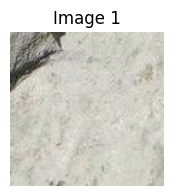

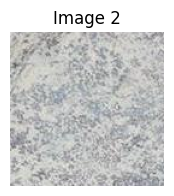

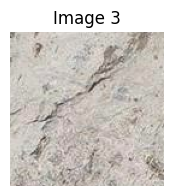

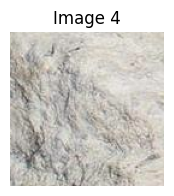

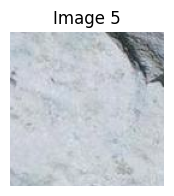

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 저장된 npy 파일 경로
npy_path = "D:/data/open/npy/train/Andesite_000001.npy"

# 1. npy 파일 읽기
images = np.load(npy_path)  # shape: (1000, 64, 64, 3)

print(f"Loaded {images.shape[0]} images with shape {images.shape[1:]}")

# 2. 앞의 5개 이미지 시각화
for i in range(5):
    plt.figure(figsize=(2, 2))
    plt.imshow(images[i])
    plt.title(f"Image {i+1}")
    plt.axis('off')
    plt.show()
